# **Importing Libraries**
This section of the code imports essential libraries for the project. I have also loaded the dataset collected which has been converted into a csv file before the import.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
from time import time as tt

!pip install --upgrade imblearn

USING_COLAB = True
if USING_COLAB:
  from google.colab import drive
  drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/MSc Big Data and Business Intelligence/Millennials_Investor_Profile.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Data Cleaning & Preprocessing**
This section explores the data quality and by appropriately organising the data and replacing 'N/A' values with the most frequent variables.

In [ ]:
data = data[(data['age'] >= 28) & (data['age'] <= 43)].copy()

X = data[['financial_literacy', 'social_class', 'age', 'funds', 'stocks', 'real_estate', 'cryptocurrency', 'bonds', 'precious_metals', 'savings_GBP']]
y = data[['risk_tolerance']]

funds_sum = X['funds'].isnull().sum()
print(funds_sum)

stocks_sum = X['stocks'].isnull().sum()
print(stocks_sum)

real_estate_sum = X['real_estate'].isnull().sum()
print(real_estate_sum)

cryptocurrency_sum = X['cryptocurrency'].isnull().sum()
print(cryptocurrency_sum)

bonds_sum = X['bonds'].isnull().sum()
print(bonds_sum)

precious_metals_sum = X['precious_metals'].isnull().sum()
print(precious_metals_sum)

44
40
82
81
89
93


In [ ]:
imptr = SimpleImputer(missing_values = np.nan, strategy='most_frequent')
imptr_st = imptr.fit(X[['funds']])
X[['funds']] = imptr_st.transform(
    X[['funds']])

imptr = SimpleImputer(missing_values = np.nan, strategy='most_frequent')
imptr_st = imptr.fit(X[['stocks']])
X[['stocks']] = imptr_st.transform(
    X[['stocks']])

imptr = SimpleImputer(missing_values = np.nan, strategy='most_frequent')
imptr_st = imptr.fit(X[['real_estate']])
X[['real_estate']] = imptr_st.transform(
    X[['real_estate']])

imptr = SimpleImputer(missing_values = np.nan, strategy='most_frequent')
imptr_st = imptr.fit(X[['cryptocurrency']])
X[['cryptocurrency']] = imptr_st.transform(
    X[['cryptocurrency']])

imptr = SimpleImputer(missing_values = np.nan, strategy='most_frequent')
imptr_st = imptr.fit(X[['bonds']])
X[['bonds']] = imptr_st.transform(
    X[['bonds']])

imptr = SimpleImputer(missing_values = np.nan, strategy='most_frequent')
imptr_st = imptr.fit(X[['precious_metals']])
X[['precious_metals']] = imptr_st.transform(
    X[['precious_metals']])

<ipython-input-20-a5e39d475364>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[['funds']] = imptr_st.transform(
<ipython-input-20-a5e39d475364>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[['stocks']] = imptr_st.transform(
<ipython-input-20-a5e39d475364>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/

In [ ]:
plt.hist(X, bins=10, color='blue', alpha=0.7)
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()

# **Data Transformation**
This section of the code encodes the categorical features using OneHotEncoder and LabelEncoder accordingly to convert the data to numerical. It also converts relevant features into the appropriate format for machine learning. This will be considered an extension of preprocessing.

In [ ]:
ct = ColumnTransformer(
    [
        (
            'onehot_categorical',
            OneHotEncoder(),
            ['funds', 'stocks', 'real_estate', 'cryptocurrency', 'bonds', 'precious_metals']
        ),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

encoded_array= ct.fit_transform(data.drop('risk_tolerance', axis=1))
encoded_col_names= ct.get_feature_names_out()
print(encoded_col_names)

new_X = pd.DataFrame(encoded_array, columns=encoded_col_names)

['funds_active' 'funds_aggressive' 'funds_passive' 'funds_nan'
 'stocks_active' 'stocks_aggressive' 'stocks_passive' 'stocks_nan'
 'real_estate_active' 'real_estate_aggressive' 'real_estate_passive'
 'real_estate_nan' 'cryptocurrency_active' 'cryptocurrency_aggresive'
 'cryptocurrency_aggressive' 'cryptocurrency_passive' 'cryptocurrency_nan'
 'bonds_active' 'bonds_aggressive' 'bonds_passive' 'bonds_nan'
 'precious_metals_active' 'precious_metals_aggressive'
 'precious_metals_passive' 'precious_metals_nan' 'financial_literacy'
 'social_class' 'age' 'savings_GBP']


In [ ]:
financial_literacy_encoded = LabelEncoder()
social_class_encoded = LabelEncoder()

lblEncoder_X = financial_literacy_encoded.fit(new_X['financial_literacy'])
lblEncoder_X2 = social_class_encoded.fit(new_X['social_class'])

new_X['financial_literacy'] = lblEncoder_X.transform(new_X['financial_literacy'])
new_X['social_class'] = lblEncoder_X2.transform(new_X['social_class'])

In [ ]:
new_X['savings_GBP'] = new_X['savings_GBP'].str.replace(',', '')
new_X[['savings_GBP']] = new_X[['savings_GBP']].astype(float)

scaler = StandardScaler()
scaler.fit(new_X[['savings_GBP']])
new_X[['savings_GBP']] = scaler.transform(new_X[['savings_GBP']])

In [ ]:
risk_tolerance_encoded = LabelEncoder()
lblEncoder_Y = risk_tolerance_encoded.fit(data['risk_tolerance'])
data['risk_tolerance'] = lblEncoder_Y.transform(data['risk_tolerance'])

y = data['risk_tolerance']

# **Data Splitting**
This part of the code splits the preprocessed dataset into training and testing data.

In [ ]:
train_X, test_X, train_y, test_y = train_test_split(new_X, y, test_size=0.2, shuffle=True, random_state=42)

In [ ]:
print(train_X.head())

   funds_active funds_aggressive funds_passive funds_nan stocks_active  \
84          0.0              0.0           0.0       1.0           1.0   
2           0.0              0.0           1.0       0.0           0.0   
94          1.0              0.0           0.0       0.0           0.0   
45          0.0              0.0           0.0       1.0           1.0   
42          0.0              1.0           0.0       0.0           1.0   

   stocks_aggressive stocks_passive stocks_nan real_estate_active  \
84               0.0            0.0        0.0                0.0   
2                0.0            1.0        0.0                1.0   
94               0.0            1.0        0.0                0.0   
45               0.0            0.0        0.0                0.0   
42               0.0            0.0        0.0                0.0   

   real_estate_aggressive  ... bonds_passive bonds_nan precious_metals_active  \
84                    0.0  ...           0.0       1.0     

# **PCA**
Principal Component Analysis is also applied to the features in the dataset for dimensionality reduction which aims to capture important patterns within the dataset considering it is 200 records which is a relatively small amount.

In [ ]:
pca = PCA()
pca_transform_train = pca.fit_transform(train_X)
pca_transform_test = pca.fit_transform(test_X)

# **Model Training**
This part of the code starts with a pipeline that creates a sequence of operations to be applied to the dataset. The code trains a Random Forest Classifier model on the transformed data.

In [ ]:
clf_ = Pipeline(
     steps=[
         ('clf', RandomForestClassifier()),
     ]
 )

hparameters = {
     'clf__n_estimators': [150, 250, 500],
     'clf__max_depth': [10, 30, 50],
     'clf__min_samples_split': [5, 10],
     'clf__max_features': ['sqrt', 'log2', None]
 }

clf_search = GridSearchCV(clf_, hparameters, scoring= "accuracy", cv=5)

In [ ]:
t0 = tt()
_ =clf_search.fit(train_X, train_y)
print(f'Time taken to train gridsearch: {tt()-t0:.2f} seconds.')

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Time taken to train gridsearch: 141.13 seconds.


# **Model Evaluation**
This sections evaluates the performance of the model and utilises a classification report to calculate relevant metrics such as accuracy, f1-score, precision and recall. There is also the inclusion of a confusion matrix to provide extra detail on the peformance of the model.

               precision    recall  f1-score   support

   minor risk       0.80      0.67      0.73         6
moderate risk       0.81      1.00      0.90        13
   major risk       0.83      0.71      0.77        14

     accuracy                           0.82        33
    macro avg       0.82      0.79      0.80        33
 weighted avg       0.82      0.82      0.81        33



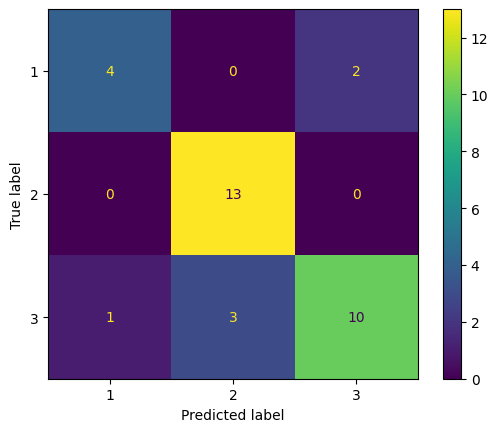

In [ ]:
best_clf = clf_search.best_estimator_
y_pred = best_clf.predict(test_X)
class_names = ['minor risk', 'moderate risk', 'major risk']
print(classification_report(test_y, y_pred, target_names = class_names))

cm= ConfusionMatrixDisplay.from_estimator(best_clf, test_X, test_y)